# 03 — Gráficas de abundancias y comparación observacional

Este notebook genera las figuras principales para la memoria:

1. Evolución de todas las abundancias para el modelo `pynucastro` arrancado en $t_0=50$ s.
2. Comparación de observables clave con bandas observacionales.
3. Figura independiente para el canal de masa 7 y el problema del litio.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
DATA_DIR = BASE / "data"
TAB_DIR = BASE / "tables"
for d in [FIG_DIR, DATA_DIR, TAB_DIR]:
    d.mkdir(exist_ok=True)

model = pd.read_csv(DATA_DIR / "bbn_evolution_t0_50s.csv")
all_models = pd.read_csv(DATA_DIR / "bbn_evolution_all_models.csv")
obs = pd.read_csv(DATA_DIR / "observational_abundances.csv")
finals = pd.read_csv(DATA_DIR / "bbn_final_compact.csv")

scienceplots no disponible, usando estilo por defecto: No module named 'scienceplots'


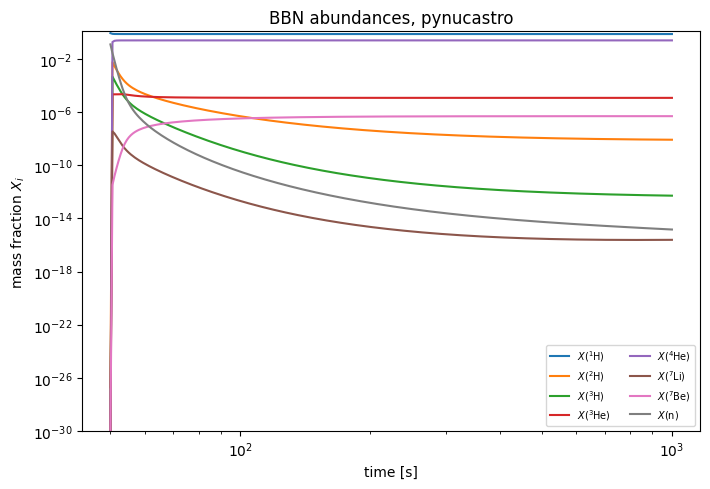

In [2]:
# Helper para detectar columnas X_i.

def abundance_columns(df):
    # Columnas de fracción másica reales. Incluimos He4; no lo quitamos porque
    # en algunas versiones no existe una columna duplicada X_he4.
    cols = [c for c in df.columns if c.startswith("X_")]
    preferred = ["X_H1", "X_H2", "X_H3", "X_He3", "X_He4", "X_Li6", "X_Li7", "X_Be7"]
    ordered = [c for c in preferred if c in cols]
    ordered += [c for c in cols if c not in ordered]
    return ordered

def pretty_label(col):
    label_map = {
        "x_h1": r"$X(^1\mathrm{H})$", "x_p": r"$X(p)$",
        "x_h2": r"$X(^2\mathrm{H})$", "x_d": r"$X(d)$",
        "x_h3": r"$X(^3\mathrm{H})$", "x_t": r"$X(t)$",
        "x_he3": r"$X(^3\mathrm{He})$", "x_he4": r"$X(^4\mathrm{He})$",
        "x_li7": r"$X(^7\mathrm{Li})$", "x_be7": r"$X(^7\mathrm{Be})$",
    }
    key = col.lower()
    if key in label_map:
        return label_map[key]
    if col.startswith("X_"):
        return r"$X($" + col[2:] + r"$)$"
    return col

def plot_all_abundances(df, outname, title):
    cols = abundance_columns(df)
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    for col in cols:
        y = df[col].clip(lower=1e-30)
        ax.loglog(df["t_s"], y, label=pretty_label(col))
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"mass fraction $X_i$")
    ax.set_ylim(1e-30, 1.2)
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / outname)
    plt.show()

plot_all_abundances(model, "fig_all_abundances_t0_50s.pdf", r"BBN abundances, pynucastro")

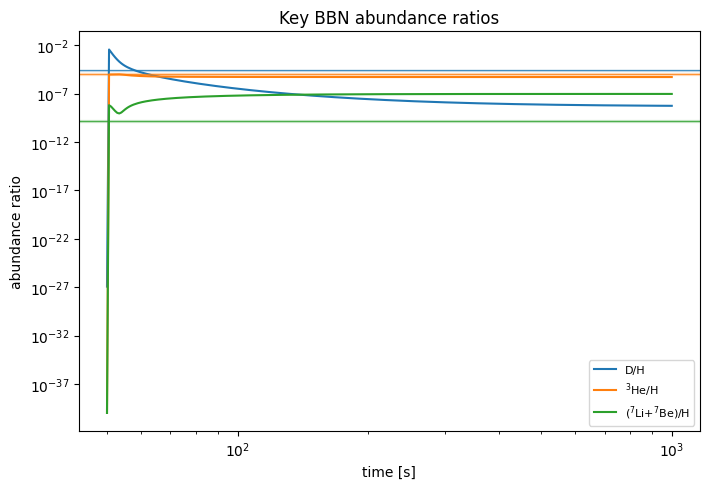

In [3]:
# Comparación de observables clave en evolución temporal.

obs_map = {row["model_column"]: row for _, row in obs.iterrows()}
plot_quantities = [
    ("D/H", r"D/H"),
    ("He3/H", r"$^3$He/H"),
    ("Li7_plus_Be7_over_H", r"$(^7$Li+$^7$Be)/H"),
]
colors = {"D/H": "C0", "He3/H": "C1", "Li7_plus_Be7_over_H": "C2"}

fig, ax = plt.subplots(figsize=(7.2, 5.0))
for col, label in plot_quantities:
    ax.loglog(model["t_s"], model[col].clip(lower=1e-40), color=colors[col], label=label)

# Bandas observacionales horizontales
for col, label in plot_quantities:
    if col in obs_map:
        val = obs_map[col]["value"]
        sig = obs_map[col]["sigma"]
        ax.axhspan(max(val-sig, 1e-40), val+sig, color=colors[col], alpha=0.15)
        ax.axhline(val, color=colors[col], lw=0.9, alpha=0.8)

ax.set_xlabel("time [s]")
ax.set_ylabel("abundance ratio")
ax.set_title("Key BBN abundance ratios")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_key_ratios_evolution_vs_observed.pdf")
plt.show()

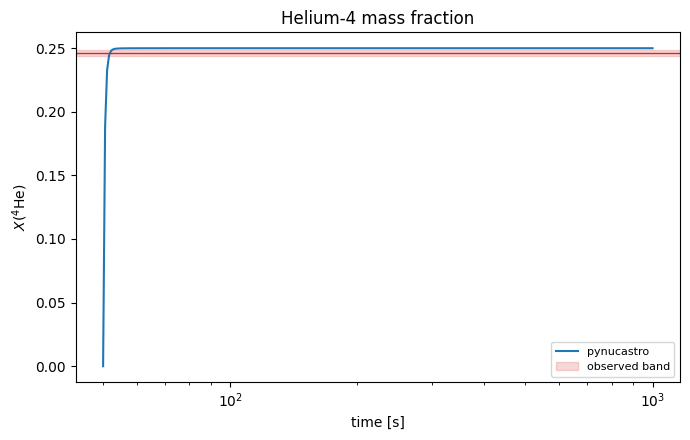

In [4]:
# Helio-4 por separado, porque es una fracción másica de orden 0.25.
fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.semilogx(model["t_s"], model["X_He4"], label="pynucastro")

he = obs[obs["model_column"] == "X_He4"].iloc[0]
ax.axhspan(he["value"]-he["sigma"], he["value"]+he["sigma"], color="C3", alpha=0.18, label="observed band")
ax.axhline(he["value"], color="C3", lw=1.0)
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$X(^4\mathrm{He})$")
ax.set_title(r"Helium-4 mass fraction")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_he4_evolution_vs_observed.pdf")
plt.show()

In [5]:
# Comparación final: modelo frente a observación.
compare_rows = []
for _, ob in obs.iterrows():
    col = ob["model_column"]
    f = finals.iloc[0]
    compare_rows.append({
        "observable": ob["observable"],
        "kind": "pynucastro",
        "value": f[col],
        "sigma": np.nan,
        "source": "pynucastro model",
    })
    compare_rows.append({
        "observable": ob["observable"],
        "kind": "observed",
        "value": ob["value"],
        "sigma": ob["sigma"],
        "source": ob["source_key"],
    })
compare = pd.DataFrame(compare_rows)
compare.to_csv(DATA_DIR / "comparison_models_vs_observed.csv", index=False)
compare

,observable,kind,value,sigma,source
0,D/H,pynucastro,5.587486e-09,NaN,pynucastro model
1,D/H,observed,2.527000e-05,3.000000e-07,Cooke2018
2,Yp_He4,pynucastro,2.498880e-01,NaN,pynucastro model
3,Yp_He4,observed,2.462000e-01,2.200000e-03,Aver2021
4,He3/H,pynucastro,5.262808e-06,NaN,pynucastro model
5,He3/H,observed,1.100000e-05,2.000000e-06,Steigman2010
6,Li7/H,pynucastro,9.465002e-08,NaN,pynucastro model
7,Li7/H,observed,1.600000e-10,3.000000e-11,FieldsLithiumReview


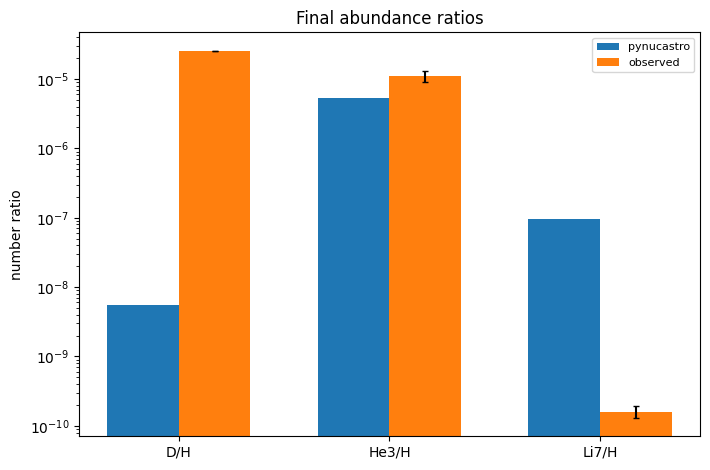

In [6]:
# Bar plot de D/H, He3/H y Li7/H en log.
small_obs = ["D/H", "He3/H", "Li7/H"]
sub = compare[compare["observable"].isin(small_obs)].copy()
fig, ax = plt.subplots(figsize=(7.2, 4.8))
labels = small_obs
x = np.arange(len(labels))
width = 0.34
kinds = ["pynucastro", "observed"]
for j, kind in enumerate(kinds):
    vals = []
    errs = []
    for lab in labels:
        row = sub[(sub["observable"] == lab) & (sub["kind"] == kind)].iloc[0]
        vals.append(row["value"])
        errs.append(row["sigma"] if np.isfinite(row["sigma"]) else 0.0)
    ax.bar(x + (j-0.5)*width, vals, width=width, label=kind, yerr=errs, capsize=2 if kind=="observed" else 0)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("number ratio")
ax.set_title("Final abundance ratios")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_final_ratios_bar_models_vs_observed.pdf")
plt.show()

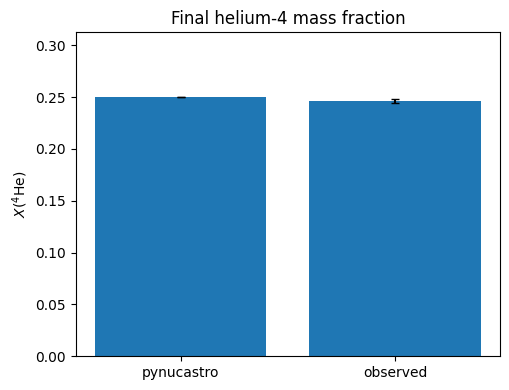

In [7]:
# Bar plot de He4 separado.
sub = compare[compare["observable"] == "Yp_He4"].copy()
fig, ax = plt.subplots(figsize=(5.2, 4.0))
labels = ["pynucastro", "observed"]
vals = [sub[sub["kind"] == k]["value"].iloc[0] for k in labels]
errs = [0.0, sub[sub["kind"] == "observed"]["sigma"].iloc[0]]
ax.bar(labels, vals, yerr=errs, capsize=3)
ax.set_ylabel(r"$X(^4\mathrm{He})$")
ax.set_title(r"Final helium-4 mass fraction")
ax.set_ylim(0, max(vals)*1.25 if max(vals) > 0 else 0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_final_he4_bar_models_vs_observed.pdf")
plt.show()

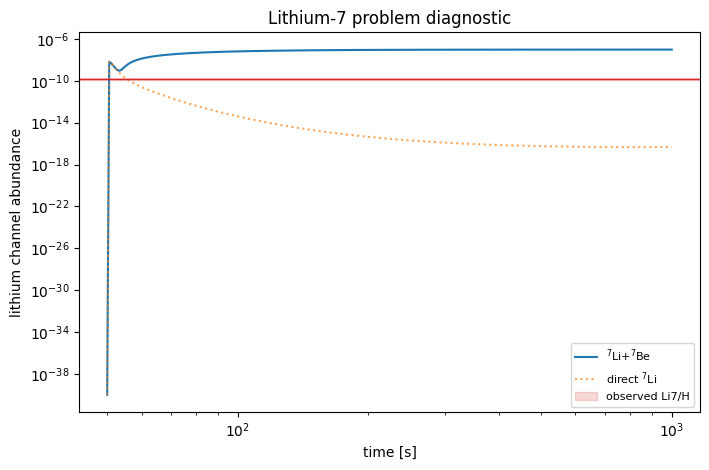

In [8]:
# Gráfica independiente del litio: evolución y valor observado.
li_obs = obs[obs["model_column"] == "Li7_plus_Be7_over_H"].iloc[0]
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.loglog(model["t_s"], model["Li7_plus_Be7_over_H"].clip(lower=1e-40), label=r"$^7$Li+$^7$Be")
if "Li7/H" in model:
    ax.loglog(model["t_s"], model["Li7/H"].clip(lower=1e-40), linestyle=":", alpha=0.7, label=r"direct $^7$Li")

ax.axhspan(li_obs["value"]-li_obs["sigma"], li_obs["value"]+li_obs["sigma"], color="C3", alpha=0.18, label="observed Li7/H")
ax.axhline(li_obs["value"], color="C3", lw=1.0)
ax.set_xlabel("time [s]")
ax.set_ylabel(r"lithium channel abundance")
ax.set_title(r"Lithium-7 problem diagnostic")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_lithium7_problem_comparison.pdf")
plt.show()